In [1]:
import gc
from pathlib import Path

import numpy as np
from statsmodels.stats.multitest import multipletests
from scipy.stats import linregress

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import anndata as ad
import scanpy as sc

%matplotlib inline

In [2]:
## FDR Calculation Function ##

def fdr_per_celltype(dge_df):
    """Add FDR-adjusted p-values and significance per cell type."""
    dge_df['p.adjusted'] = None
    dge_df['significant_fdr'] = False
    
    for celltype, group in dge_df.groupby('assay'):
        rejected, pvals_corrected, _, _ = multipletests(group['p.value'], method='fdr_bh')
        dge_df.loc[group.index, 'p.adjusted'] = pvals_corrected
        dge_df.loc[group.index, 'significant_fdr'] = rejected
    
    return dge_df

In [3]:
# ## Import AnnData Object ##

# adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata_annotated_w_celltypist_scanvi.h5ad')

# ## Toss Stressed Glia & Doublets ##

# adata = adata[~(adata.obs['subclass_annotations'] == 'Stressed Glia') & ~adata.obs['pred_dbl']].copy()
# gc.collect()

# # Create Pseudobulk Col ##

# adata.obs['Donor_Sample'] = adata.obs['Donor'].astype('str') + '_' + adata.obs['Sample Name'].astype('str')

In [4]:
# ## Known Genes In Deleted Regions ##

# # https://bioinfo.uth.edu/SZGR/display/showGeneset #

# CLASSIC_22q11 = ['TBX1', "COMT", "DGCR8", "TANGO2"]

# ALL_22q11 = ["DERL3", "LRP5L", "SGSM1", "C22orf15", "LOC284890", "C22orf36", "PIWIL3", "GSTT2B",
#                     "DDTL", "SMARCB1", "VPREB3", "SERPIND1", "MAPK1", "HIRA", "ZNF74", "CLTCL1",
#                     "VPREB1", "GSTT2", "MMP11", "ZNF70", "CRYBB1", "CRKL", "BCR", "ADRBK2",
#                     "MN1", "CHEK2", "APOL2", "C22orf28", "LOC652968", "FBXO7", "PVALB", "PPARA",
#                     "TPST2", "PES1", "SEZ6L", "PITPNB", "TFIP11", "C22orf31", "ASPHD2", "KREMEN1",
#                     "ZNRF3", "ASCC2", "HSCB", "CCDC117", "RHBDD3", "C22orf24", "TIMP3", "TBC1D10A",
#                     "XBP1", "EWSR1", "LIF", "LIMK2", "DRG1", "NEFH", "NF2", "OSM",
#                     "RFPL1", "SMTN", "TCN2", "NIPSNAP1", "THOC5", "MTMR3", "GAL3ST1", "SFI1",
#                     "SF3A1", "RASL10A", "GAS2L1", "MORC2", "SEC14L2", "PATZ1", "PISD", "OSBP2",
#                     "RNF185", "PIK3IP1", "EMID1", "SELM", "HORMAD2", "DUSP18", "CABP7", "RNF215",
#                     "SEC14L3", "SEC14L4", "SLC35E4", "LOC550631", "SLC5A4", "C22orf30", "DGCR5",
#                     "DGCR6L", "SUSD2", "SCZD4", "BID", "IL17RA", "BCL2L13", "TUBA8", "GAB4",
#                     "CCT8L2", "XKR3", "TRMT2A", "RTDR1", "CECR2", "YPEL1", "LOC51233", "MED15",
#                     "UPB1", "CECR1", "DGCR8", "GNB1L", "EIF4ENIF1", "SLC2A11", "THAP7", "OR11H1",
#                     "C22orf13", "SLC25A18", "MYO18B", "CRYBB2", "CRYBB3", "CRYBA4", "PLA2G3",
#                     "APOL4", "ACO2", "ARVCF", "GSC2", "PI4KA", "SEPT5", "PRODH", "RANBP1",
#                     "SLC7A4", "SLC25A1", "TBX1", "CLDN5", "UBE2L3", "UFD1L", "CDC45L", "SNAP29",
#                     "DGCR2", "TXNRD2", "USP18", "HIC2", "TSSK2", "SDF2L1", "PPIL2", "ZDHHC8",
#                     "PEX26", "MICAL3", "MRPL40", "RTN4R", "C22orf29", "KLHL22", "SCARF2",
#                     "C22orf25", "AIFM3", "CCDC116", "FLJ42953", "LOC440792", "COMT", "GP1BB",
#                     "DGCR6", "LZTR1", "DGCR14", "GNAZ", "TOP3B", "RAB36", "PPM1F", "PRAME",
#                     "DKFZP434P211", "LOC96610", "ZNF280A", "ZNF280B", "ADORA2A", "DDT",
#                     "GGT1", "GSTT1", "IGLL1", "MIF", "SNRPD3", "SPECC1L", "CABIN1"]

# CLASSIC_3q29 = ['DLG1', "PAK2", "TFRC", "C3orf34"]
# BORDERLINE_3q29 = ['HES1', "CLDN1", "OPA1"]
# ALL_3q29 = adata.var_names[adata.var_names.isin(CLASSIC_3q29 + BORDERLINE_3q29)].tolist()

# CLASSIC_15q13 = ['HERC2', 'CHRFAM7A', 'CHP', 'FMN1']
# BORDERLINE_15q13 = ['SCG5', 'SLC12A6', 'GREM1', 'MAP1A']
# ALL_15q13 = adata.var_names[adata.var_names.isin(CLASSIC_15q13 + BORDERLINE_15q13)].tolist()

In [5]:
## Read in DEG Lists ##

CSV_PATH = '/mnt/sdb/scz_meta_analysis_processed/dge_signatures/dreamlet_dges/disease_analyses/'

# by manuscript #
dge_fernando = pd.read_csv(Path(CSV_PATH) / 'dreamlet_fernando_dge_scz_results.csv')
dge_shin = pd.read_csv(Path(CSV_PATH) / 'dreamlet_shin_dge_scz_results.csv')
dge_purcell = pd.read_csv(Path(CSV_PATH) / 'dreamlet_purcell_dge_scz_results.csv')
dge_sebastian = pd.read_csv(Path(CSV_PATH) / 'dreamlet_sebastian_dge_scz_results.csv')
dge_sawada = pd.read_csv(Path(CSV_PATH) / 'dreamlet_sawada_dge_scz_results.csv')
dge_notaras = pd.read_csv(Path(CSV_PATH) / 'dreamlet_notaras_dge_scz_results.csv')
dge_rao = pd.read_csv(Path(CSV_PATH) / 'dreamlet_rao_dge_scz_results.csv')
dge_walsh_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_22q11_dge_scz_results.csv')
dge_walsh_15q13 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_walsh_15q13_dge_scz_results.csv')

# by disease #
dge_nrxn1 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_nrxn1_combined.csv')
dge_22q11 = pd.read_csv(Path(CSV_PATH) / 'dreamlet_22q11_combined.csv')
dge_idiopathic = pd.read_csv(Path(CSV_PATH) / 'dreamlet_idiopathic_combined.csv')
dge_15q13 = dge_walsh_15q13
dge_3q29 = dge_purcell

In [6]:
# Make Assay ID #

# Put all dataframes in a dictionary
dge_dfs = {
    'dge_fernando': dge_fernando,
    'dge_shin': dge_shin,
    'dge_purcell': dge_purcell,
    'dge_sebastian': dge_sebastian,
    'dge_sawada': dge_sawada,
    'dge_notaras': dge_notaras,
    'dge_rao': dge_rao,
    'dge_walsh_22q11': dge_walsh_22q11,
    'dge_walsh_15q13': dge_walsh_15q13,
    'dge_nrxn1': dge_nrxn1,
    'dge_22q11': dge_22q11,
    'dge_idiopathic': dge_idiopathic,
    'dge_15q13': dge_15q13,
    'dge_3q29': dge_3q29}

# Add assay_ID column to each
for name, df in dge_dfs.items():
    df['assay_ID'] = df['assay'].astype(str) + ' | ' + df['ID'].astype(str)

In [7]:
## Calculate FDR ##

dge_nrxn1 = fdr_per_celltype(dge_nrxn1)
dge_22q11 = fdr_per_celltype(dge_22q11)
dge_idiopathic = fdr_per_celltype(dge_idiopathic)

In [8]:
## Calculate Significant Gene Lists ##

# refine metaanalysis dataframes to significant hits across all studies 
significant_nrxn1_df = dge_nrxn1[(dge_nrxn1['p.adjusted'] < 0.05) & (dge_nrxn1['n.studies'] == 2)]
significant_22q11_df = dge_22q11[(dge_22q11['p.adjusted'] < 0.05) & (dge_22q11['n.studies'] == 3)]
significant_idiopathic_df = dge_idiopathic[(dge_idiopathic['p.adjusted'] < 0.05) & (dge_idiopathic['n.studies'] == 2)]

# make significnat gene lists
significant_nrxn1 = significant_nrxn1_df['ID'].tolist()
significant_22q11 = significant_22q11_df['ID'].tolist()
significant_idiopathic = significant_idiopathic_df['ID'].tolist()

# make sets from lists #
set_nrxn1 = set(significant_nrxn1)
set_22q11 = set(significant_22q11)
set_idiopathic = set(significant_idiopathic)

# make overlap lists ##
set_22q11_nrxn1 = set_22q11.intersection(set_nrxn1) 
set_22q11_idiopathic = set_22q11.intersection(set_idiopathic) 
set_nrnxn1_idiopathic = set_nrxn1.intersection(set_idiopathic) 

In [9]:
dge_15q13[(dge_15q13['adj.P.Val'] < 0.05)]

,assay,ID,logFC,AveExpr,t,P.Value,adj.P.Val,B,z.std,dataset,assay_ID


In [10]:
dge_3q29[(dge_3q29['adj.P.Val'] < 0.05)]

,assay,ID,logFC,AveExpr,t,P.Value,adj.P.Val,B,z.std,dataset,assay_ID
0,Radial Glia SOX2+VIM+FABP7+,UBXN7,-1.410543,5.178853,-13.097255,7.995727e-07,0.018796,6.357204,-13.097255,purcell,Radial Glia SOX2+VIM+FABP7+ | UBXN7
1,Radial Glia SOX2+VIM+FABP7+,PAK2,-1.201422,6.834729,-12.554585,1.118057e-06,0.018796,6.147169,-12.554585,purcell,Radial Glia SOX2+VIM+FABP7+ | PAK2
2,Radial Glia SOX2+VIM+FABP7+,NEAT1,-1.604934,8.615706,-12.475494,1.175337e-06,0.018796,6.154063,-12.475494,purcell,Radial Glia SOX2+VIM+FABP7+ | NEAT1
3,IPC EOMES+NEUROG2+PAX6+,CADM1,2.920552,5.867342,8.295579,1.482729e-06,0.018796,-2.307061,8.295579,purcell,IPC EOMES+NEUROG2+PAX6+ | CADM1
4,Radial Glia SOX2+VIM+FABP7+,SAT1,-1.201880,7.602492,-12.103017,1.493006e-06,0.018796,5.912923,-12.103017,purcell,Radial Glia SOX2+VIM+FABP7+ | SAT1
5,Radial Glia SOX2+VIM+FABP7+,TMEM159,-1.539923,3.495084,-11.795281,1.828545e-06,0.018796,5.401540,-11.795281,purcell,Radial Glia SOX2+VIM+FABP7+ | TMEM159
6,Radial Glia SOX2+VIM+FABP7+,BLOC1S6,-1.103334,6.054103,-11.776155,1.852020e-06,0.018796,5.664562,-11.776155,purcell,Radial Glia SOX2+VIM+FABP7+ | BLOC1S6
7,Radial Glia SOX2+VIM+FABP7+,RNF168,-1.560908,4.710141,-11.635163,2.035807e-06,0.018796,5.498788,-11.635163,purcell,Radial Glia SOX2+VIM+FABP7+ | RNF168
8,Radial Glia SOX2+VIM+FABP7+,BTG3,-0.975040,7.187944,-11.524175,2.194816e-06,0.018796,5.552051,-11.524175,purcell,Radial Glia SOX2+VIM+FABP7+ | BTG3
9,Radial Glia SOX2+VIM+FABP7+,LIPG,-1.263478,3.902009,-10.940261,3.296072e-06,0.025076,4.967994,-10.940261,purcell,Radial Glia SOX2+VIM+FABP7+ | LIPG


In [11]:
def add_directional_consistency(df):
    # Remove duplicate columns
    df = df.loc[:, ~df.columns.duplicated()].copy()
    
    # Identify logFC columns
    logfc_cols = [col for col in df.columns if col.startswith('logFC')]
    
    def check_direction(row):
        vals = row[logfc_cols].dropna()
        
        if len(vals) <= 1:
            return np.nan  # not enough data
        
        signs = np.sign(vals)
        signs = signs[signs != 0]  # optionally ignore zeros
        
        if len(signs) == 0:
            return np.nan
        
        return len(set(signs)) == 1  # True if all same sign
    
    # Add new column
    df['directionally_consistent'] = df.apply(check_direction, axis=1)
    
    return df

In [12]:
## Examining 22q11 Meta-Analysis ##

dge_shin_rao = dge_shin.merge(dge_rao, left_on=['assay', 'ID', 'assay_ID'],
                              right_on=['assay', 'ID', 'assay_ID'], how='inner', suffixes=['_shin', '_rao'])

dge_walsh_22q11_renamed = dge_walsh_22q11.add_suffix('_walsh')
dge_walsh_22q11_renamed = dge_walsh_22q11_renamed.rename(columns={'assay_walsh': 'assay', 'ID_walsh': 'ID', 'assay_ID_walsh':'assay_ID'})

dge_shin_rao_walsh_22q11 = dge_shin_rao.merge(dge_walsh_22q11_renamed,
                                              left_on=['assay', 'ID', 'assay_ID'],
                                              right_on=['assay', 'ID', 'assay_ID'], how='inner')

significant_22q11_df_logfc = significant_22q11_df.merge(dge_shin_rao_walsh_22q11[['assay', 'ID', 'assay_ID', 
                                                                            'logFC_rao','logFC_shin', 'logFC_walsh']],
                                                  left_on=['assay', 'ID', 'assay_ID'], 
                                                  right_on=['assay', 'ID', 'assay_ID'], how='left') 

significant_22q11_df_logfc = add_directional_consistency(significant_22q11_df_logfc)

logfc_cols_22q11 = [i for i in significant_22q11_df_logfc.columns if 'logFC' in i]
significant_22q11_df_logfc['mean_logFC'] = significant_22q11_df_logfc[logfc_cols_22q11].mean(axis=1)

dc_significant_22q11_df_logfc = significant_22q11_df_logfc[significant_22q11_df_logfc['directionally_consistent'] == True]

significant_22q11_df_logfc['directionally_consistent'].mean()

0.5676126878130217

In [13]:
## Examining NRXN1 Meta-Analysis ##

dge_sebastian_fernando = dge_sebastian.merge(dge_fernando, left_on=['assay', 'ID', 'assay_ID'],
                              right_on=['assay', 'ID', 'assay_ID'], how='inner', suffixes=['_sebastian', '_fernando'])

significant_nrxn1_df_logfc = significant_nrxn1_df.merge(dge_sebastian_fernando[['assay', 'ID', 'assay_ID', 
                                                                            'logFC_sebastian', 'logFC_fernando']],
                                                                            left_on=['assay', 'ID', 'assay_ID'], 
                                                                            right_on=['assay', 'ID', 'assay_ID'], how='left') 

significant_nrnx1_df_logfc = add_directional_consistency(significant_nrxn1_df_logfc)

logfc_cols_nrxn1 = [i for i in significant_nrnx1_df_logfc.columns if 'logFC' in i]
significant_nrnx1_df_logfc['mean_logFC'] = significant_nrnx1_df_logfc[logfc_cols_nrxn1].mean(axis=1)

dc_significant_nrxn1_df_logfc = significant_nrnx1_df_logfc[significant_nrnx1_df_logfc['directionally_consistent'] == True]

significant_nrnx1_df_logfc['directionally_consistent'].mean()

0.7546972860125261

In [14]:
## Examining Idiopathic Meta-Analysis ##

dge_sawada_notaras = dge_sawada.merge(dge_notaras, left_on=['assay', 'ID', 'assay_ID'],
                              right_on=['assay', 'ID', 'assay_ID'], how='inner', suffixes=['_sawada', '_notaras'])

significant_idiopathic_df_logfc = significant_idiopathic_df.merge(dge_sawada_notaras[['assay', 'ID', 'assay_ID', 
                                                                                'logFC_sawada', 'logFC_notaras']],
                                                                                left_on=['assay', 'ID', 'assay_ID'], 
                                                                                right_on=['assay', 'ID', 'assay_ID'], how='left') 

significant_idiopathic_df_logfc = add_directional_consistency(significant_idiopathic_df_logfc)

logfc_cols_idiopathic = [i for i in significant_idiopathic_df_logfc.columns if 'logFC' in i]
significant_idiopathic_df_logfc['mean_logFC'] = significant_idiopathic_df_logfc[logfc_cols_idiopathic].mean(axis=1)

dc_significant_idiopathic_df_logfc = significant_idiopathic_df_logfc[significant_idiopathic_df_logfc['directionally_consistent'] == True]

significant_idiopathic_df_logfc['directionally_consistent'].mean()

0.744927536231884

In [15]:
dc_significant_22q11_df_logfc['assay'].value_counts()

assay
Radial Glia SOX2+VIM+FABP7+                    194
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+     50
Hindbrain Neurons NR2F2+PBX3+LHX1+              45
Proliferative Radial Glia SOX2+HES6+TOP2A+      39
Radial Glia SOX2+PAX6+FABP7+                     7
Mixed Neurons FGF12+GRIN2B+CAMK2B+               5
Name: count, dtype: int64

In [16]:
dc_significant_idiopathic_df_logfc['assay'].value_counts()

assay
Radial Glia SOX2+PAX6+FABP7+                  166
Proliferative Radial Glia SOX2+HES6+TOP2A+     83
Hindbrain Neurons NR2F2+PBX3+LHX1+              5
Radial Glia SOX2+VIM+FABP7+                     3
Name: count, dtype: int64

In [17]:
dc_significant_nrxn1_df_logfc['assay'].value_counts()

assay
Dorsal Forebrain Neuron FOXG1+EMX1+NEUROG1+    300
Astrocyte GFAP+AQP4+HOPX+                      134
IPC EOMES+NEUROG2+PAX6+                         88
Proliferative Radial Glia SOX2+HES6+TOP2A+      85
Mixed Neurons FGF12+GRIN2B+CAMK2B+              64
Radial Glia SOX2+PAX6+FABP7+                    31
Radial Glia SOX2+VIM+FABP7+                     18
Hindbrain Neurons NR2F2+PBX3+LHX1+               2
Mesenchymal-like cells VIM+VCAN+SPARC+           1
Name: count, dtype: int64

In [18]:
def plot_logfc_correlations_grid(dataframe, x_col='logFC_rao', y_col='logFC_shin', min_genes=10):

    assays = dataframe['assay'].unique()
    valid_assays = [a for a in assays if dataframe[dataframe['assay'] == a].shape[0] >= min_genes]

    n_assays = len(valid_assays)
    ncols = 3
    nrows = int(np.ceil(n_assays / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
    axes = np.array(axes).flatten()

    for i, celltype in enumerate(valid_assays):

        ax = axes[i]
        temp = dataframe[dataframe['assay'] == celltype]

        sns.regplot(data=temp, x=x_col, y=y_col,
                    scatter_kws={'alpha': 0.6},
                    line_kws={'color': 'red'},
                    ax=ax)

        r = temp[[x_col, y_col]].corr().iloc[0, 1]

        ax.text(0.05, 0.95, f"R = {r:.2f}",
                transform=ax.transAxes,
                ha='left', va='top', fontsize=11)

        ax.set_title(celltype)
        ax.set_xlabel(x_col)
        ax.set_ylabel(y_col)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

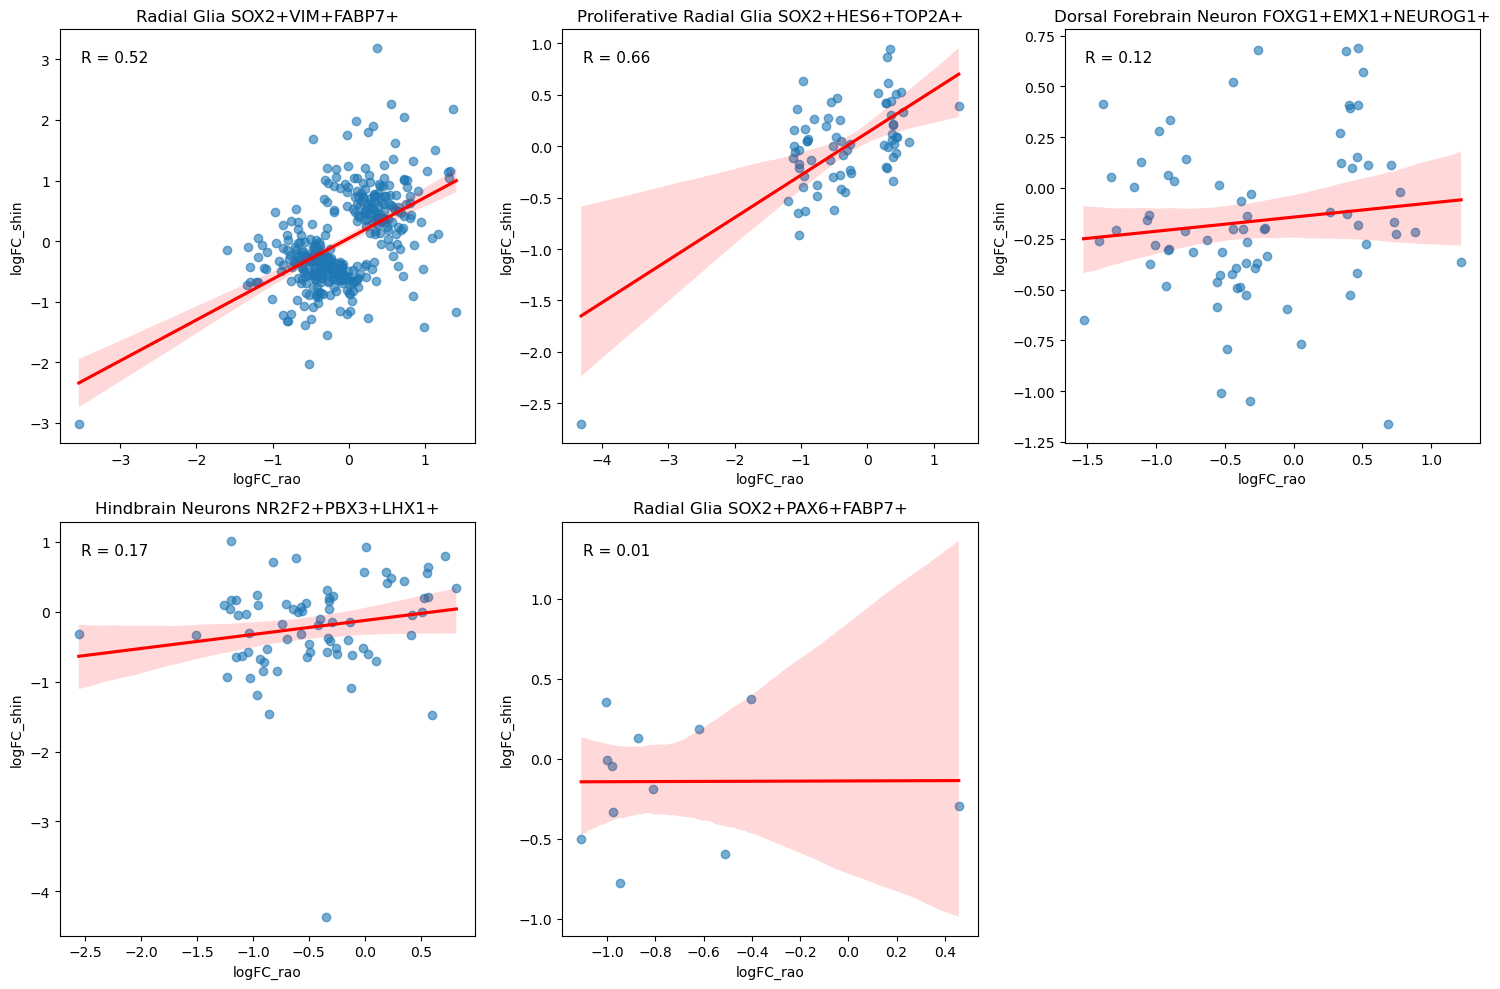

In [19]:
plot_logfc_correlations_grid(significant_22q11_df_logfc, x_col='logFC_rao', y_col='logFC_shin')

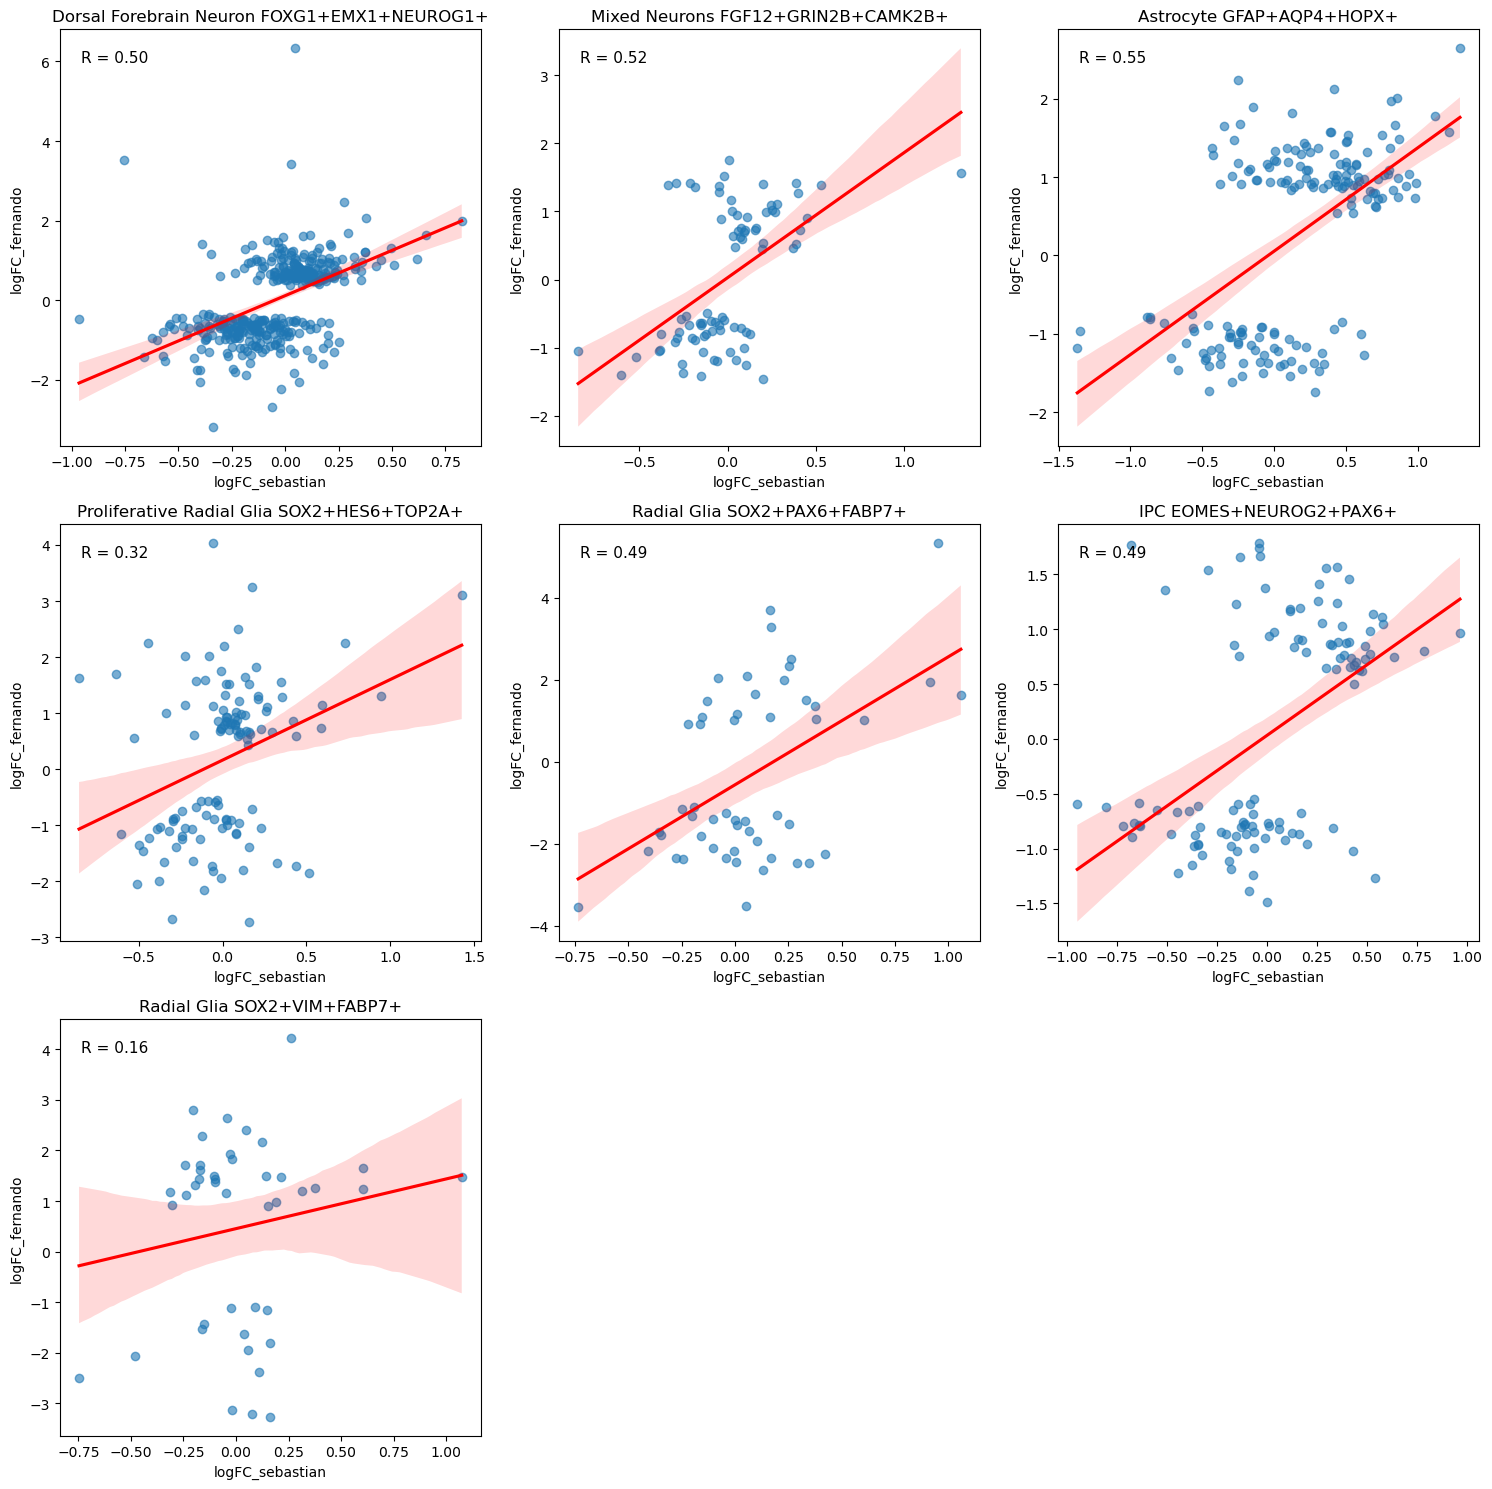

In [20]:
plot_logfc_correlations_grid(significant_nrxn1_df_logfc, x_col='logFC_sebastian', y_col='logFC_fernando')

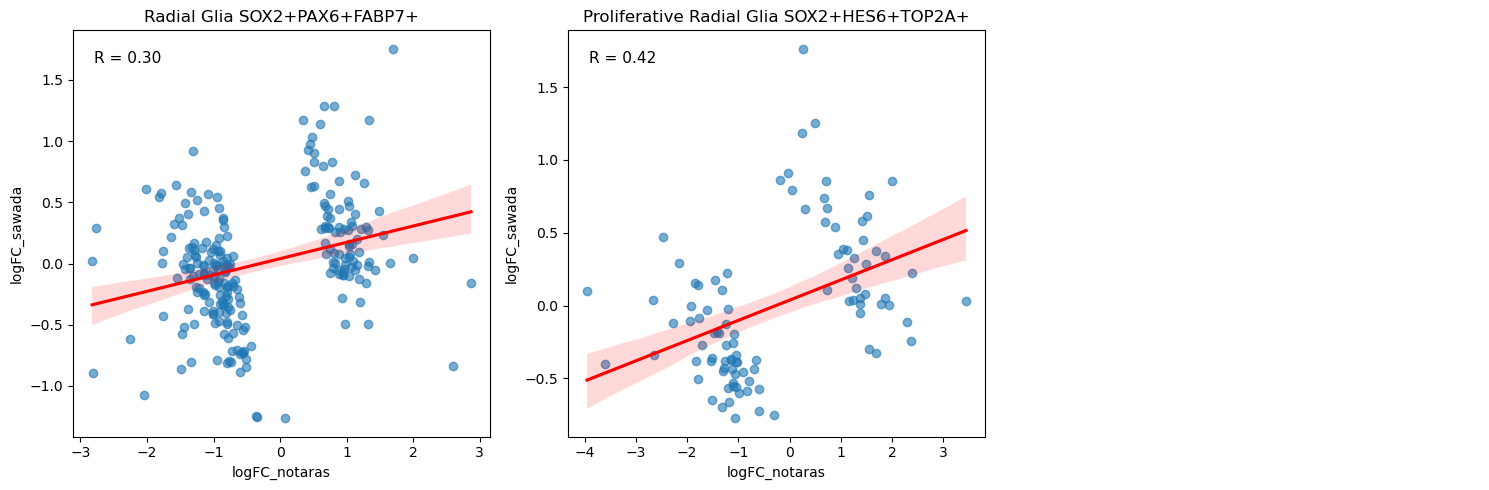

In [21]:
plot_logfc_correlations_grid(significant_idiopathic_df_logfc, x_col='logFC_notaras', y_col='logFC_sawada')

In [22]:
dge_sebastian_fernando = dge_sebastian_fernando.merge(dge_nrxn1[['assay_ID', 'p.adjusted', 'significant_fdr']], 
                                                      left_on='assay_ID', right_on='assay_ID', how='left')

dge_shin_rao_walsh_22q11 = dge_shin_rao_walsh_22q11.merge(dge_22q11[['assay_ID', 'p.adjusted', 'significant_fdr']], 
                                                          left_on='assay_ID', right_on='assay_ID', how='left')

dge_sawada_notaras = dge_sawada_notaras.merge(dge_idiopathic[['assay_ID', 'p.adjusted', 'significant_fdr']], 
                                                          left_on='assay_ID', right_on='assay_ID', how='left')

In [23]:
def plot_genome_wide_correlations(dge_df, x_col='logFC_sebastian', y_col='logFC_fernando', dataset_label='', save=False):

    for assay in dge_df['assay'].unique():

        temp_dge_df = dge_df[dge_df['assay'] == assay]

        # Drop NaNs just in case
        temp_dge_df = temp_dge_df[[x_col, y_col, 'significant_fdr']].dropna()

        x = temp_dge_df[x_col]
        y = temp_dge_df[y_col]

        # Regression stats
        slope, intercept, r_value, p_value, std_err = linregress(x, y)
        r_squared = r_value ** 2

        # format p-value
        if p_value < 1e-16:
            p_text = "p < 1e-16"
        else:
            p_text = f"p = {p_value:.2e}"

        plt.figure(figsize=(6, 5))
        ax = sns.scatterplot(data=temp_dge_df, x=x_col, y=y_col, hue='significant_fdr', alpha=0.7)
        sns.regplot(data=temp_dge_df, x=x_col, y=y_col, scatter=False, color='black', line_kws={"linewidth": 2})
        plt.title(assay)

        # annotation (top-left)
        plt.text(0.05, 0.95, f"$R^2$ = {r_squared:.3f}\n{p_text}",
            transform=plt.gca().transAxes,
            ha='left', va='top', fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

        # move legend outside
        ax.legend_.remove()
        
        if save:
            plt.savefig(f"/home/deepak/datasets/scz_meta_analysis/panels/{dataset_label}_{assay}_genome_wide_correlation.png", bbox_inches="tight")

        plt.show()

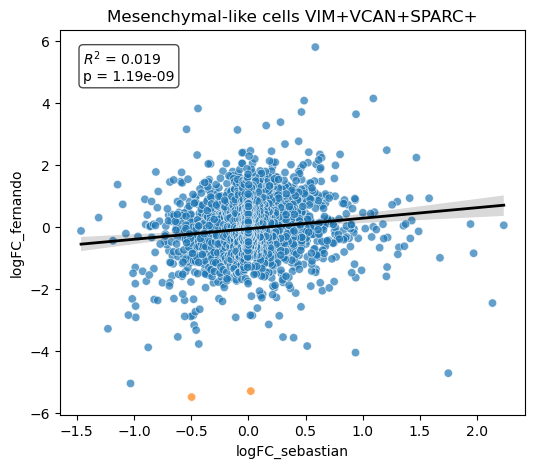

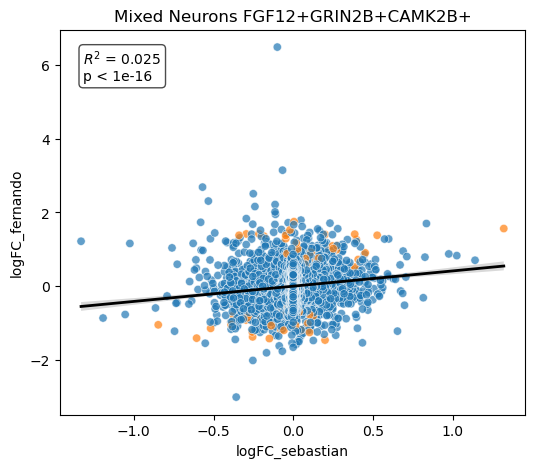

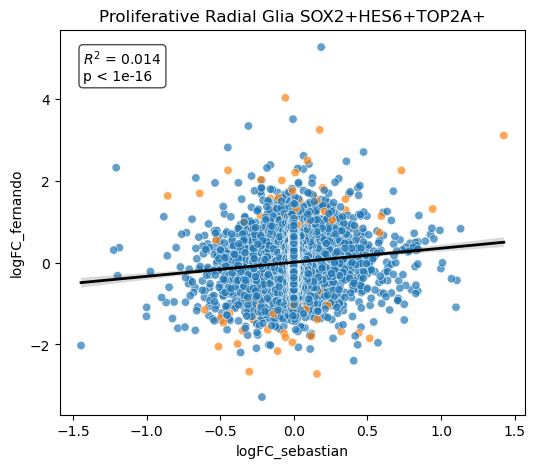

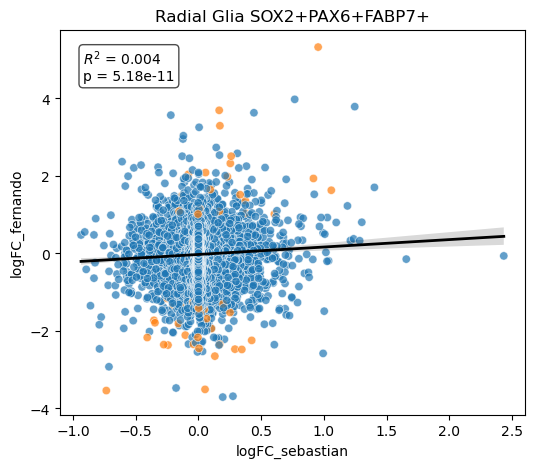

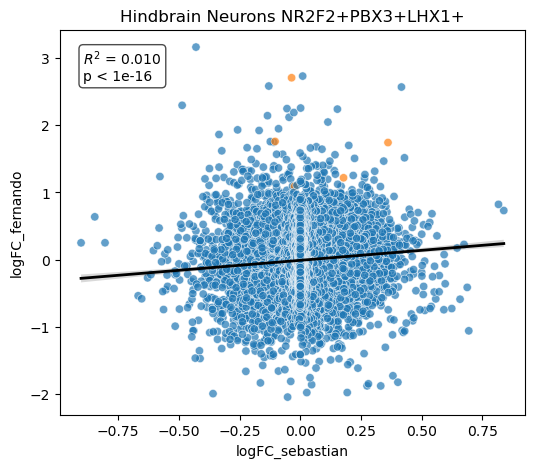

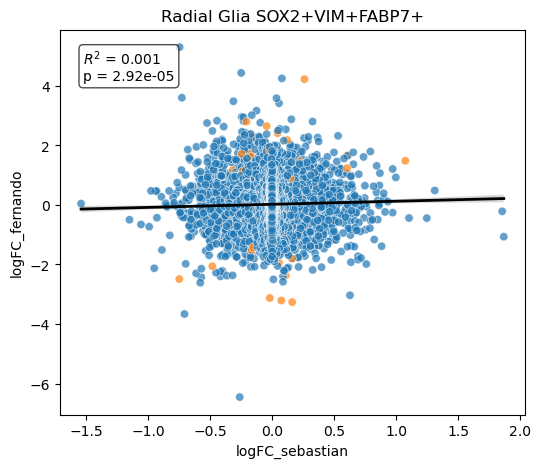

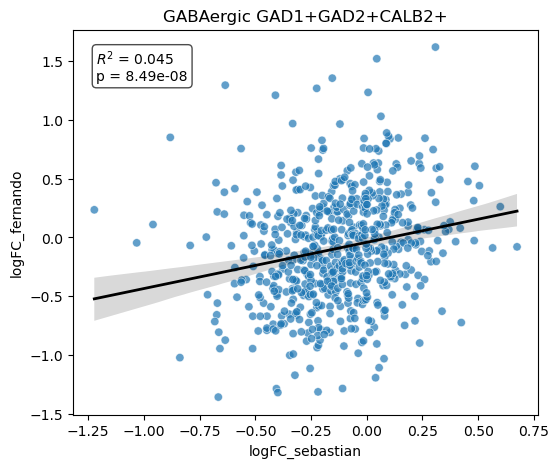

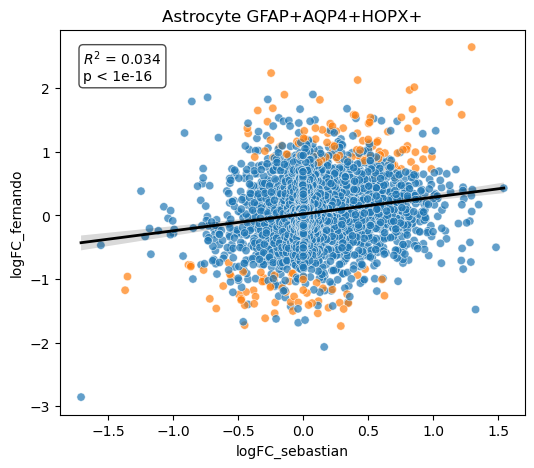

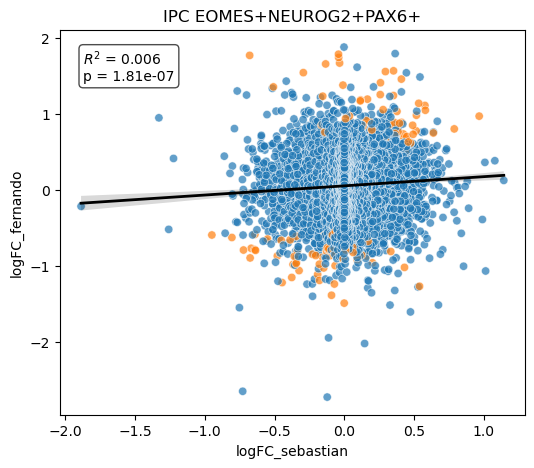

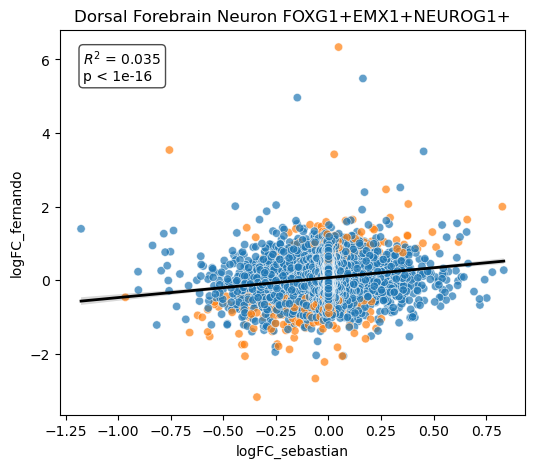

In [24]:
plot_genome_wide_correlations(dge_sebastian_fernando, dataset_label='NRXN1', 
                              x_col='logFC_sebastian', y_col='logFC_fernando', save=True)

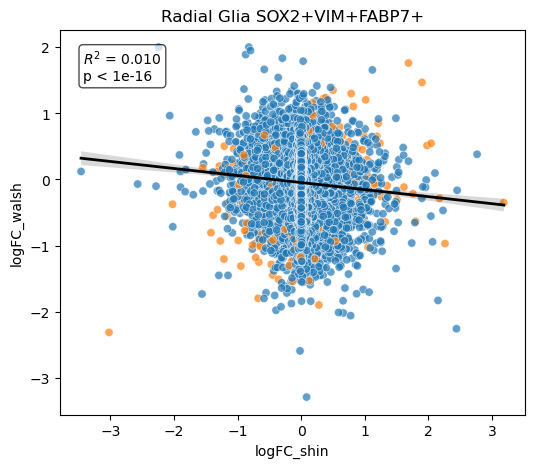

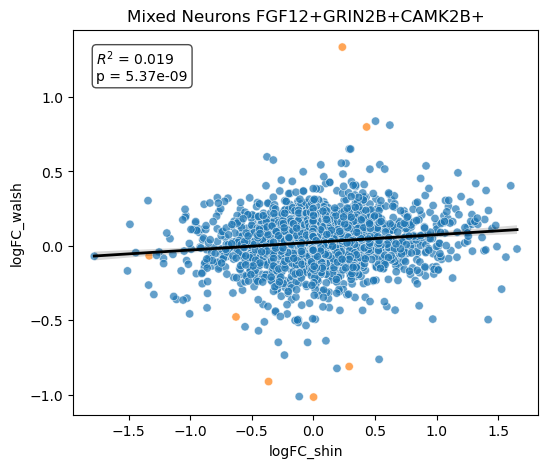

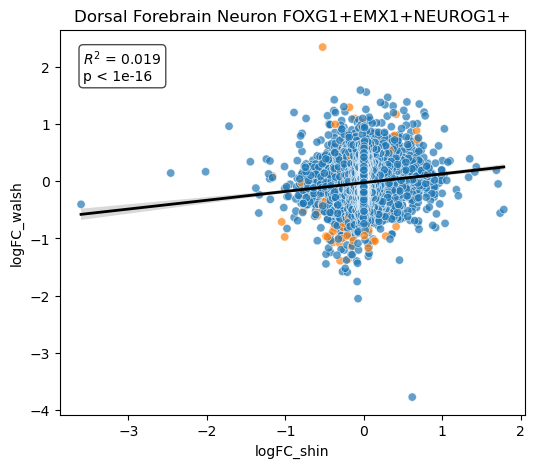

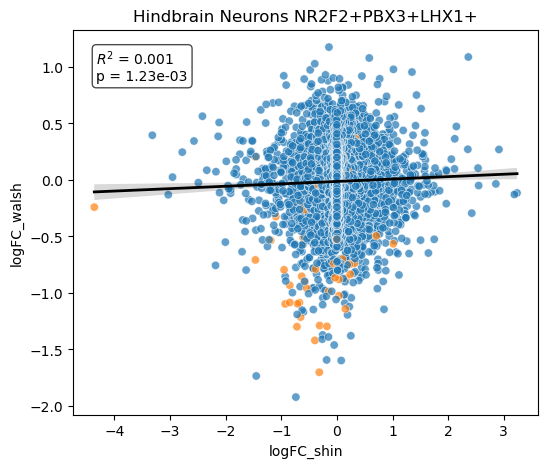

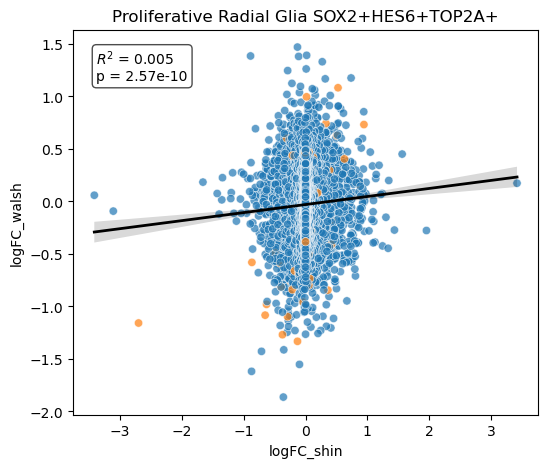

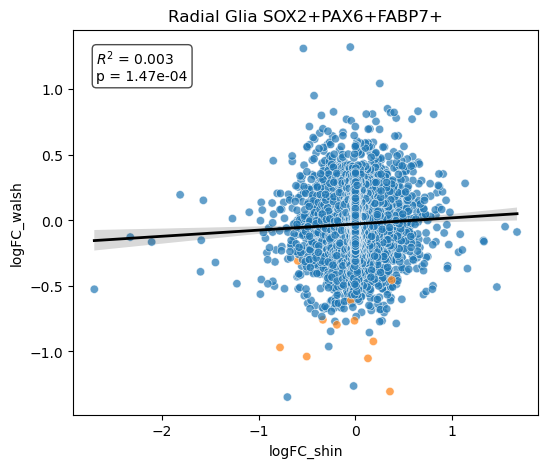

In [25]:
plot_genome_wide_correlations(dge_shin_rao_walsh_22q11, x_col='logFC_shin', y_col='logFC_walsh', 
                              save=True, dataset_label='22q11_Shin_Walsh')

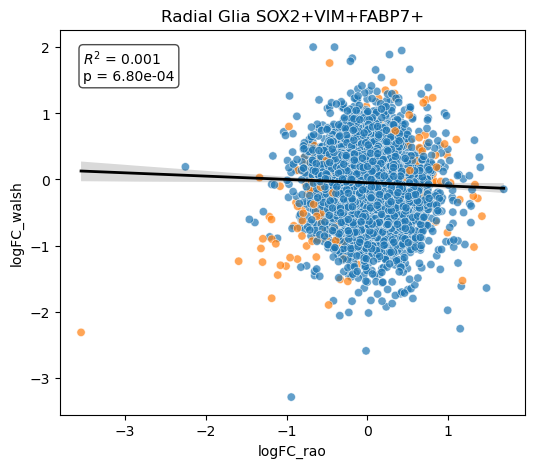

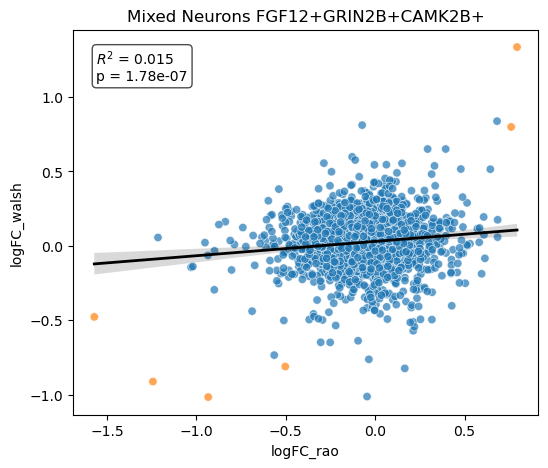

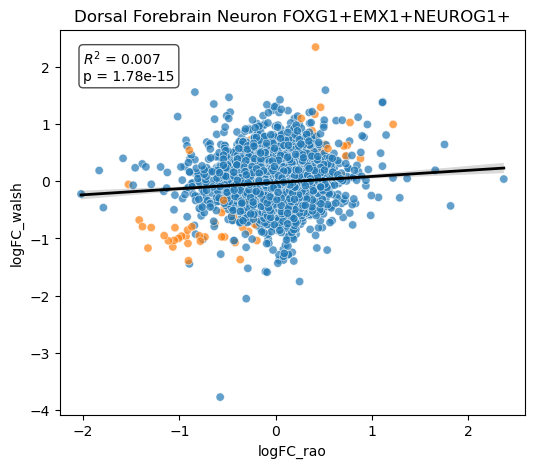

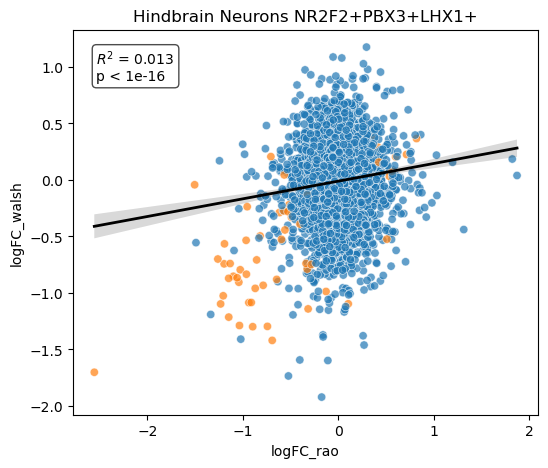

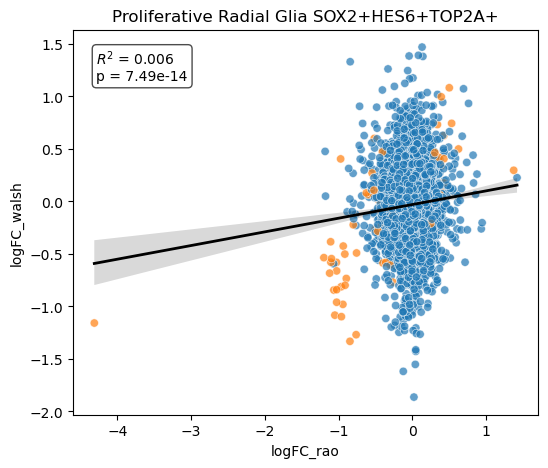

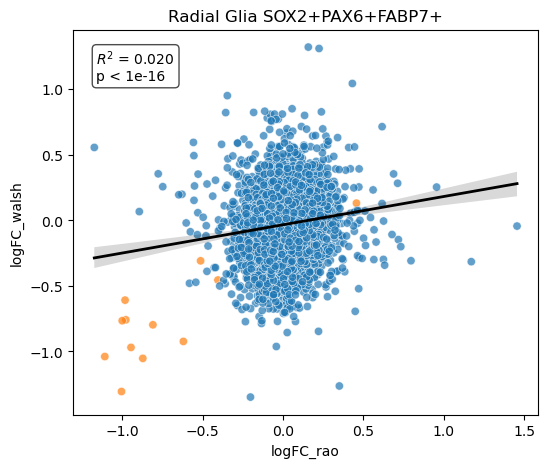

In [26]:
plot_genome_wide_correlations(dge_shin_rao_walsh_22q11, x_col='logFC_rao', y_col='logFC_walsh', 
                              save=True, dataset_label='22q11_Rao_Walsh')

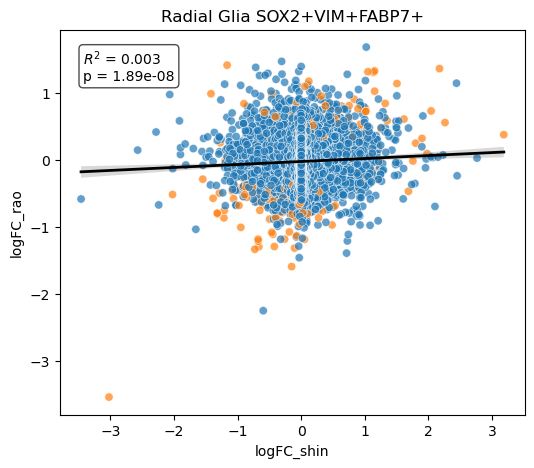

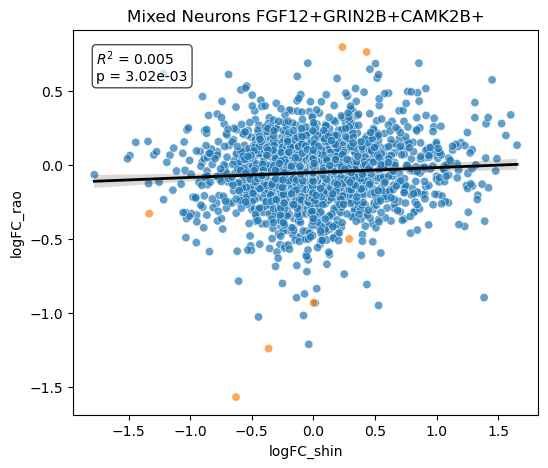

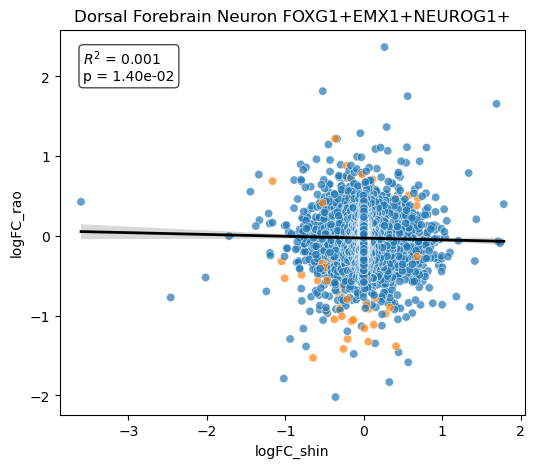

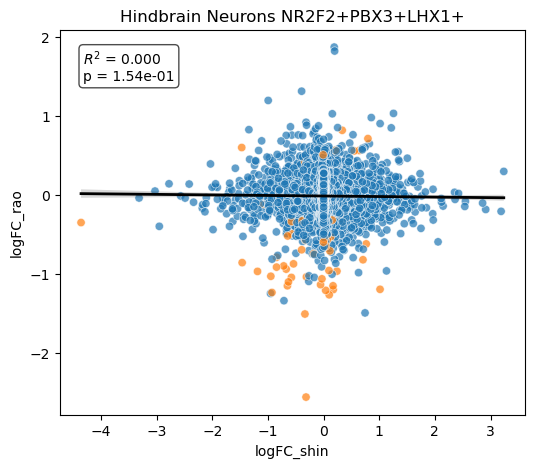

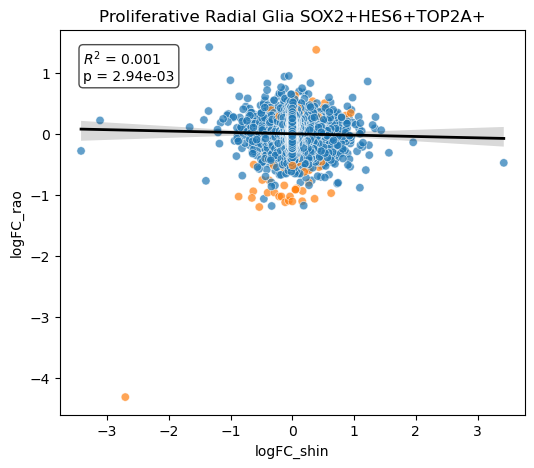

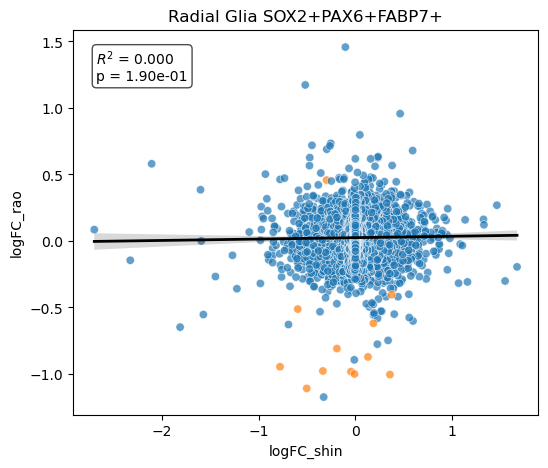

In [27]:
plot_genome_wide_correlations(dge_shin_rao_walsh_22q11, x_col='logFC_shin', y_col='logFC_rao', 
                              save=True, dataset_label='22q11_Shin_Rao')

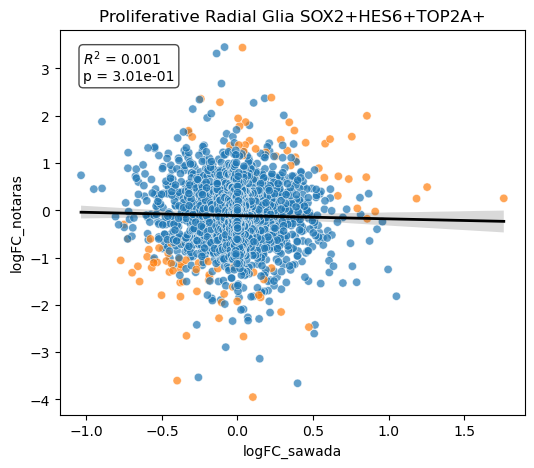

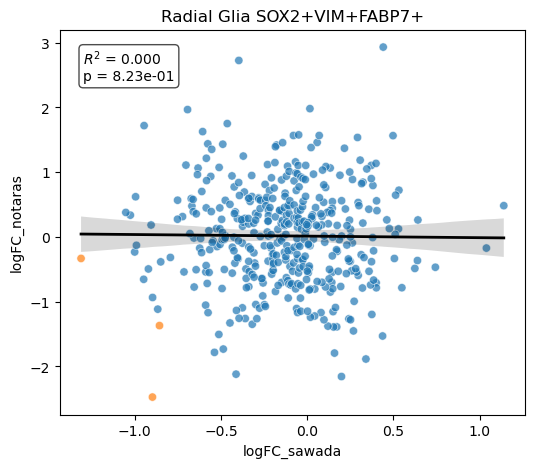

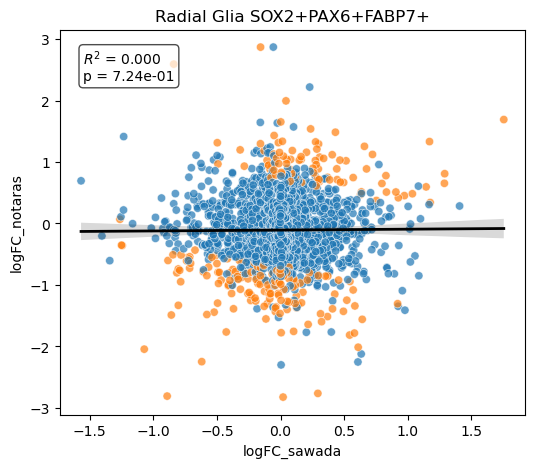

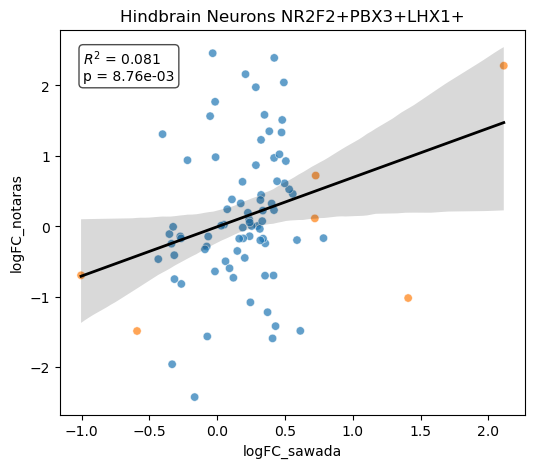

In [28]:
plot_genome_wide_correlations(dge_sawada_notaras, x_col='logFC_sawada', y_col='logFC_notaras', 
                              save=True, dataset_label='Idiopathic')